In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o")

small_llm = ChatOpenAI(model="gpt-4o-mini")

In [3]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    query: str
    context: list
    answer: str

graph_builder = StateGraph(AgentState)

In [4]:
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field
from typing import Literal

class Route(BaseModel):
    target: Literal['income_tax', 'llm', 'real_estate_tax'] = Field(
        description="The target for the query to answer"
    )

router_system_prompt = """
You are an expert at routing a user's question to 'income_tax', 'llm', or 'real_estate_tax'.
'income_tax' contains information about income tax up to December 2024.
'real_estate_tax' contains information about real estate tax up to December 2024.
if you think the question is not related to either 'income_tax' or 'real_estate_tax';
you can route it to 'llm'."""


router_prompt = ChatPromptTemplate.from_messages([
    ('system', router_system_prompt),
    ('user', '{query}')
])

structured_router_llm = small_llm.with_structured_output(Route)

def router(state: AgentState) -> Literal['income_tax', 'real_estate_tax', 'llm']:
    query = state['query']
    router_chain = router_prompt | structured_router_llm 
    route = router_chain.invoke({'query': query})

    return route.target

In [5]:
from langchain_core.output_parsers import StrOutputParser

def call_llm(state: AgentState) -> AgentState:
    query = state['query']
    llm_chain = small_llm | StrOutputParser()
    llm_answer = llm_chain.invoke(query)
    return {'answer': llm_answer}

/Users/jys/code/study/study-llm-agent/venv/lib/python3.11/site-packages/langsmith/client.py:278: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(
/Users/jys/code/study/study-llm-agent/venv/lib/python3.11/site-packages/langsmith/client.py:278: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(
/Users/jys/code/study/study-llm-agent/venv/lib/python3.11/site-packages/langsmith/client.py:278: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(
/Users/jys/code/study/study-llm-agent/venv/lib/python3.11/site-packages/langsmith/client.py:278: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(
/Users/jys/code/study/study-llm-agent/venv/lib/python3.11/site-packages/langsmith/client.py:278: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warni

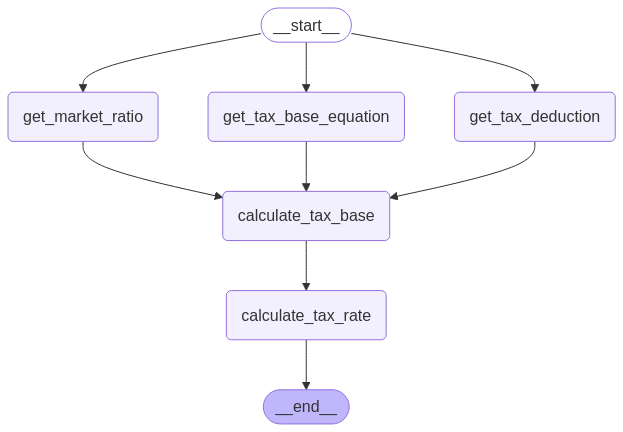

In [6]:
from income_tax_graph import graph as income_tax_agent
from real_estate_tax_graph import graph as real_estate_tax_agent

graph_builder.add_node('income_tax', income_tax_agent)
graph_builder.add_node('real_estate_tax', real_estate_tax_agent)
graph_builder.add_node('llm', call_llm)

In [7]:
from langgraph.graph import START, END

graph_builder.add_conditional_edges(
    START,
    router,
    {
        'income_tax': 'income_tax',
        'real_estate_tax': 'real_estate_tax',
        'llm': 'llm'
    }
)
graph_builder.add_edge('income_tax', END)
graph_builder.add_edge('real_estate_tax', END)
graph_builder.add_edge('llm', END)

In [8]:
graph = graph_builder.compile()

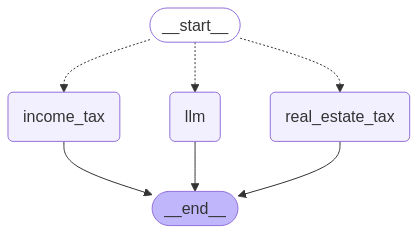

In [9]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [10]:
initial_state = {'query': '소득세란 무엇인가요?'}
graph.invoke(initial_state)

{'query': '소득세란 무엇인가요?',
 'context': [Document(id='16448b23-6cf8-430a-87d5-b18557d9b62b', metadata={'source': './documents/income_tax.txt'}, page_content="제2장 거주자의 종합소득 및 퇴직소득에 대한 납세의무 <개정 2009. 12. 31.>\n제3절 비과세\n  [제3절 비과세 2009. 12. 31.]\n제12조(비과세소득) 다음 각 호의 소득에 대해서는 소득세를 과세하지 아니한다. <개정 2010. 12. 27. 2011. 7. 25., 2011. 9. 15, 2012. 1. 1, 2013. 1. 1, 2013. 2. 2, 2014. 1. 1, 2014. 3. 18, 2014. 12. 15, 2016. 12. 20., 2018. 3. 20, 2018. 12. 31, 2019. 12. 10., 2019. 12. 31, 2020. 12. 29, 2022. 8. 12, 2022. 12. 31, 2023. 8. 8, 2023. 12. 31.>\n1. ‘공익신탁법’에 따른 공익재단의 이익\n  가. 농. 임. 반을 작업 생산에 이용하여 물로서 발생하는 소득\n  나. 1개 국의 주택임대소득자 주택임대소득(제99조의 규정에 따른 기준시가가 12억원을 초과하는 주택 및 국외에 소재하는 주택의 임대소득을 제외한다) 또는 해상 주택세기금의 정하는 충분금액의 합계금이 2천 만원 이하인 자의 주택임대소득의 산정 또는 해당 과세기간까지 발생하는 소득으로 한정한다.\n  다. 대변동형으로 정하는 통의가 발행하는 소득\n  라. 대변동형으로 정하는 전종주제 제도를 통해 발생하는 소득\n  마. 조정기간이 1년 이상인 임차(賃) 노임(賃) 발생 또는 양도소득으로 연 600만원 이하 금액, 이 경우 조정기간 및 세액의 필요사항은 대변동형으로 정한다.\n  바. 대변동형으로 정하는 작목재배업에 발생하는 소득\n  사. 대변동형으로 정하는 사업이 아닌 소득이 발생하는